In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [4]:
df = pd.read_csv("../data/ethiopia.csv")
df["Country"] = "Ethiopia"

In [5]:
df["DATE"] = pd.to_datetime(df["YEAR"] * 1000 + df["DOY"], format="%Y%j")
df["Month"] = df["DATE"].dt.month

In [6]:
df.replace(-999, np.nan, inplace=True)

In [7]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

df = df.drop_duplicates()

Duplicate rows: 0


In [8]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,DATE,Month
count,4108.000000,4108.000000,4108.00000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,16.06850,23.199175,10.227544,12.971631,3.633795,68.408588,1.979998,3.575246,77.037529,9.697724,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,10.03000,15.650000,1.170000,3.560000,0.000000,14.420000,0.460000,0.790000,76.360000,2.120000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,14.82000,21.110000,8.417500,9.830000,0.020000,59.030000,1.407500,2.720000,76.980000,8.070000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,16.04000,22.740000,10.990000,13.030000,0.820000,71.120000,1.970000,3.530000,77.040000,10.270000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,17.36000,25.170000,12.220000,16.020000,4.580000,80.802500,2.480000,4.370000,77.100000,11.710000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,21.53000,30.930000,15.680000,23.240000,82.300000,91.930000,4.130000,7.490000,77.370000,13.520000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,1.89805,2.751471,2.607256,3.821239,6.289061,14.735838,0.689093,1.123721,0.099484,2.362462,NaN,3.477046


### Interpretation of Summary Statistics

The dataset (2015–2026) shows a generally stable climate with moderate variability.

Temperature (T2M) averages 16.1°C, with limited variation, indicating a mild and stable climate with clear seasonal changes.
Precipitation is highly skewed: most days are dry, but occasional heavy rainfall events occur (up to 82.3 mm).
Humidity (RH2M) is moderately high on average (~68%), but varies widely between dry and humid conditions.
Wind speed is generally low (~2 m/s), showing calm conditions most of the time.
Pressure (PS) is very stable, indicating no major atmospheric disturbances.

Overall, the data reflects a mild climate with stable conditions and intermittent rainfall events.

In [9]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_percent
})

,Missing Count,Missing %
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### Missing Data Summary

The dataset has no missing values (0%) across all variables, including climate, temporal, and categorical features.

This indicates a complete and well-structured dataset, requiring no imputation or missing-value handling before analysis.

In [10]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = np.abs(zscore(df[cols], nan_policy='omit'))
outliers = (z_scores > 3).sum()

print(outliers)

137


In [11]:
df = df.fillna(method="ffill")

# Optional: drop rows with too many missing values
df = df[df.isna().mean(axis=1) < 0.3]

C:\Users\Alienware\AppData\Local\Temp\ipykernel_19924\1397755152.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


In [24]:
df.to_csv("../data/ethiopia_clean.csv", index=False)

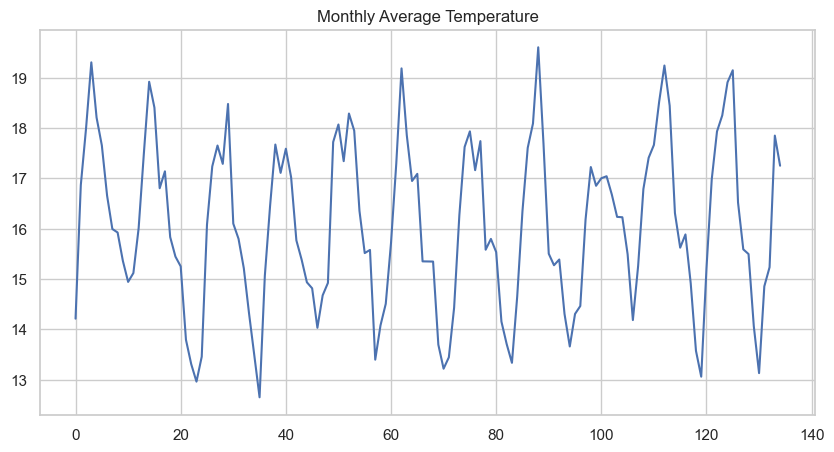

In [16]:
monthly_temp = df.groupby(["YEAR", "Month"])["T2M"].mean().reset_index()

plt.figure(figsize=(10,5))
plt.plot(monthly_temp["T2M"])
plt.title("Monthly Average Temperature")
plt.show()

### Monthly Average Temperature Interpretation

The plot shows a clear repeating seasonal pattern in temperature over time.

Temperature fluctuates regularly between about 13°C and 19.5°C, indicating consistent yearly cycles.


Peaks and drops repeat in a stable rhythm, suggesting strong seasonality with no long-term warming or cooling trend.


The overall variability is moderate, meaning the climate is stable but seasonally driven rather than volatile.


In summary, the temperature is cyclical and seasonal with stable long-term behavior.

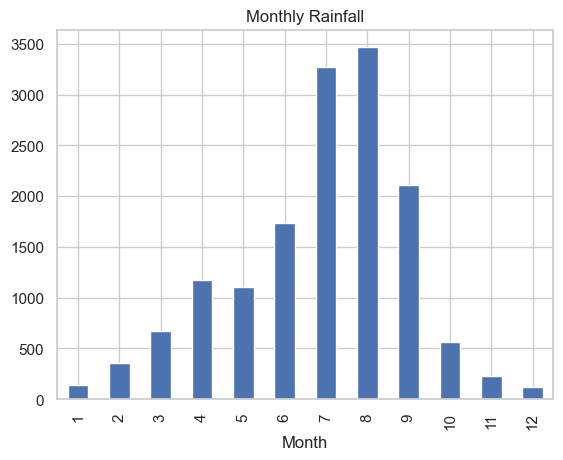

In [17]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum()

monthly_rain.plot(kind="bar")
plt.title("Monthly Rainfall")
plt.show()

### monthly rainfall Interpretation

The rainfall pattern shows a strong seasonal trend, with low rainfall at the beginning and end of the year and a sharp peak in mid-year. The highest rainfall occurs in July and August, indicating the main rainy season. 

Rainfall increases steadily from March to June, then declines rapidly after September. This suggests a single dominant wet season and a prolonged dry period.

Overall, the data indicates high variability and a clear climate pattern rather than random distribution.


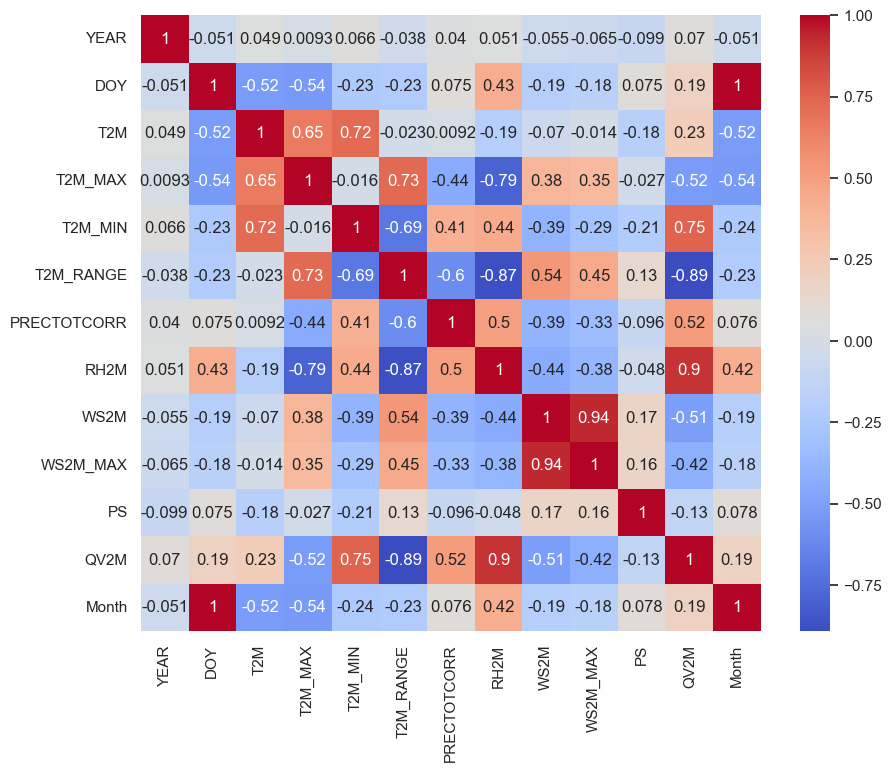

In [19]:
corr = df.select_dtypes(include=[np.number]).corr()

plt.figure(figsize=(10,8))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

### Correlation Heatmap – Key Insights

Temperature:
T2M is strongly correlated with T2M_MAX and T2M_MIN.
T2M_RANGE increases with higher max temps and lower min temps.

Humidity:
RH2M is negatively correlated with temperature extremes and range, but strongly positively correlated with QV2M (~0.90).

Precipitation:
PRECTOTCORR increases with humidity and decreases with temperature range → wetter days have less variability.

Wind:
WS2M and WS2M_MAX are highly correlated (~0.94).

Seasonality:
DOY/Month correlate with temperature, showing seasonal patterns; YEAR shows little trend.

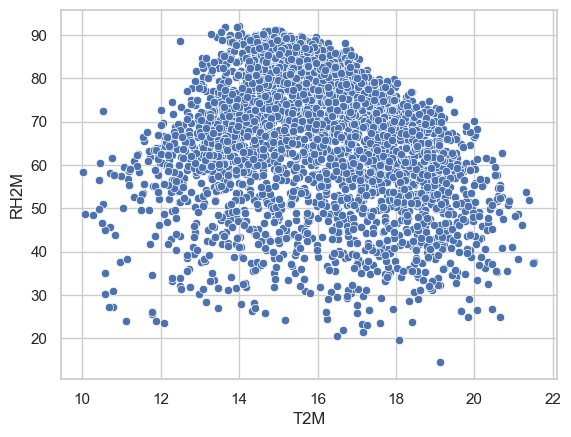

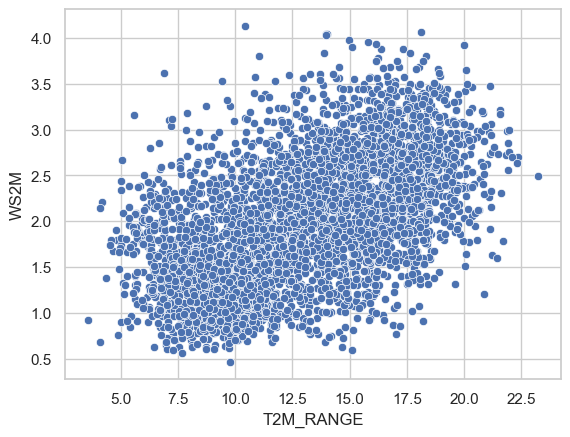

In [20]:
sns.scatterplot(x="T2M", y="RH2M", data=df)
plt.show()

sns.scatterplot(x="T2M_RANGE", y="WS2M", data=df)
plt.show()

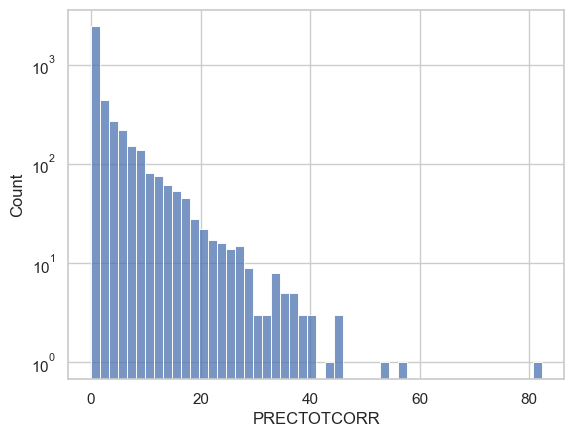

In [21]:
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.yscale("log")
plt.show()

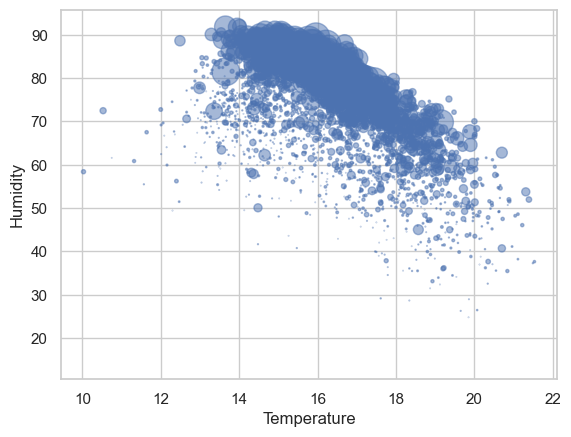

In [22]:
plt.scatter(df["T2M"], df["RH2M"], s=df["PRECTOTCORR"]*10, alpha=0.5)
plt.xlabel("Temperature")
plt.ylabel("Humidity")
plt.show()

### Dense downward trend:

The highest concentration of points occurs between 13–20°C, where humidity drops from ~90% to ~40%, forming a clear downward slope.

### Interpretation:
This indicates a strong inverse relationship—as temperature increases, humidity decreases.

### Physical meaning:
As air warms, its capacity to hold moisture increases, so relative humidity falls unless additional moisture is added.